In [102]:
import numpy as np
import pandas as pd

In [103]:
df = pd.read_csv('spam.csv',encoding='latin1')

In [104]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3210,ham,"OH YEAH,AND HAV A GREAT TIME IN NEWQUAY-SEND M...",NaN,NaN,NaN
1387,ham,Hope ur head doesn't hurt 2 much ! Am ploughin...,NaN,NaN,NaN
2672,ham,Super msg da:)nalla timing.,NaN,NaN,NaN
451,ham,Thanks for this hope you had a good day today,NaN,NaN,NaN
5078,ham,Mark works tomorrow. He gets out at 5. His wor...,NaN,NaN,NaN


In [105]:
df.shape

(5609, 5)

In [106]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5609 entries, 0 to 5608
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5609 non-null   object
 1   v2          5609 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 219.2+ KB


In [108]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [109]:
df.sample(5)

,v1,v2
1913,ham,You want to go?
3896,ham,No. Thank you. You've been wonderful
2740,ham,Nothing. Can...
1909,ham,Then u going ikea str aft dat?
458,ham,1.20 that call cost. Which i guess isnt bad. M...


In [110]:
# renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
5340,ham,Are u awake? Is there snow there?
3102,ham,"U so lousy, run already come back then half de..."
2377,spam,YES! The only place in town to meet exciting a...
4331,ham,ALSO TELL HIM I SAID HAPPY BIRTHDAY
4728,ham,I've reached already.


In [111]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [112]:
df['target'] = encoder.fit_transform(df['target'])

In [113]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [114]:
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [115]:
# check for duplicate values
df.duplicated().sum()

403

In [116]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [117]:
df.duplicated().sum()

0

In [118]:
df.shape

(5206, 2)

## 2.EDA

In [119]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [120]:
# Keep only rows where the target is either 0 or 1
df = df[df['target'].isin([0, 1])]


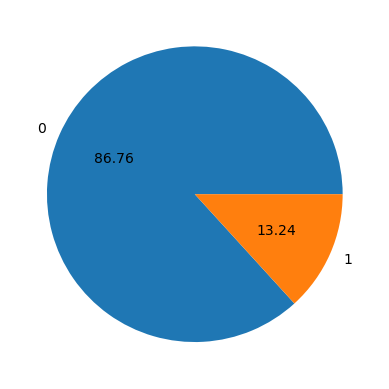

In [121]:
import matplotlib.pyplot as plt

# Get the value counts of the target column
counts = df['target'].value_counts()

# Use the index of counts as labels
plt.pie(counts, labels=counts.index, autopct="%0.2f")
plt.show()


In [122]:
# Data is imbalanced

In [123]:
import nltk

In [124]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [125]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [126]:
df['num_characters'] = df['text'].apply(len)

In [127]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [128]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [129]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [130]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [131]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [132]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5205.000000,5205.000000,5205.000000
mean,79.249568,18.446302,1.967915
std,58.169573,13.283509,1.444306
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,2.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [133]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.684234,17.123782,1.820195
std,56.435582,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [134]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,689.000000,689.000000,689.000000
mean,135.390421,27.114659,2.936139
std,32.477765,7.279705,1.460323
min,13.000000,2.000000,1.000000
25%,125.000000,24.000000,2.000000
50%,148.000000,28.000000,3.000000
75%,158.000000,32.000000,4.000000
max,225.000000,46.000000,9.000000


In [135]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

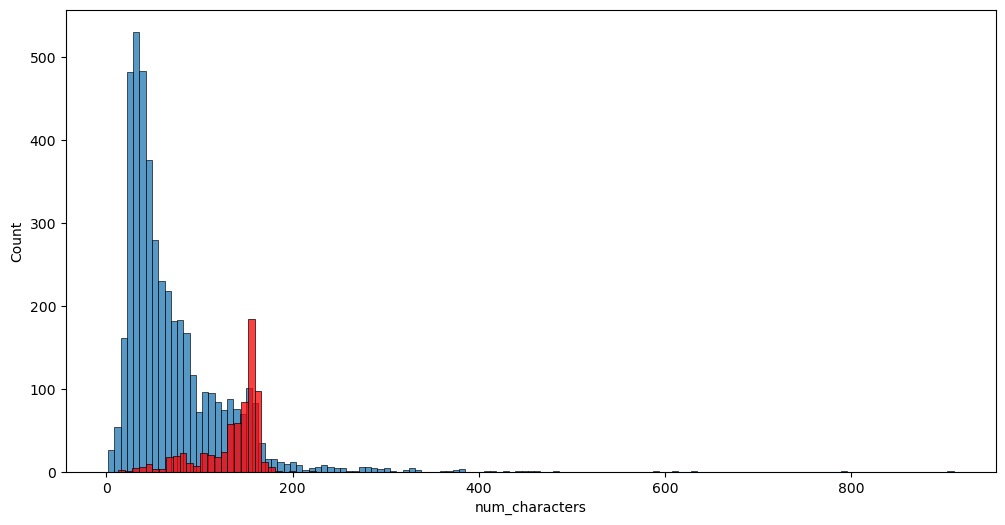

In [136]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

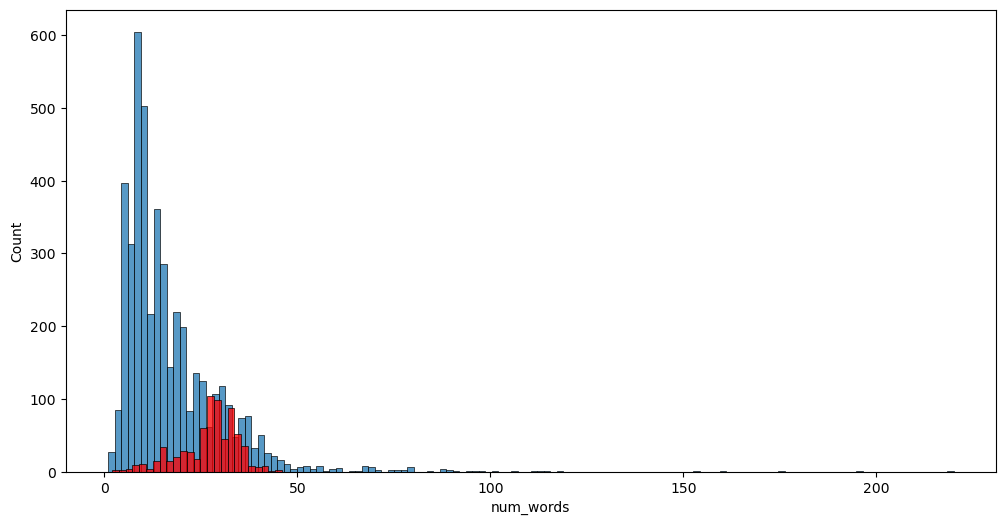

In [137]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

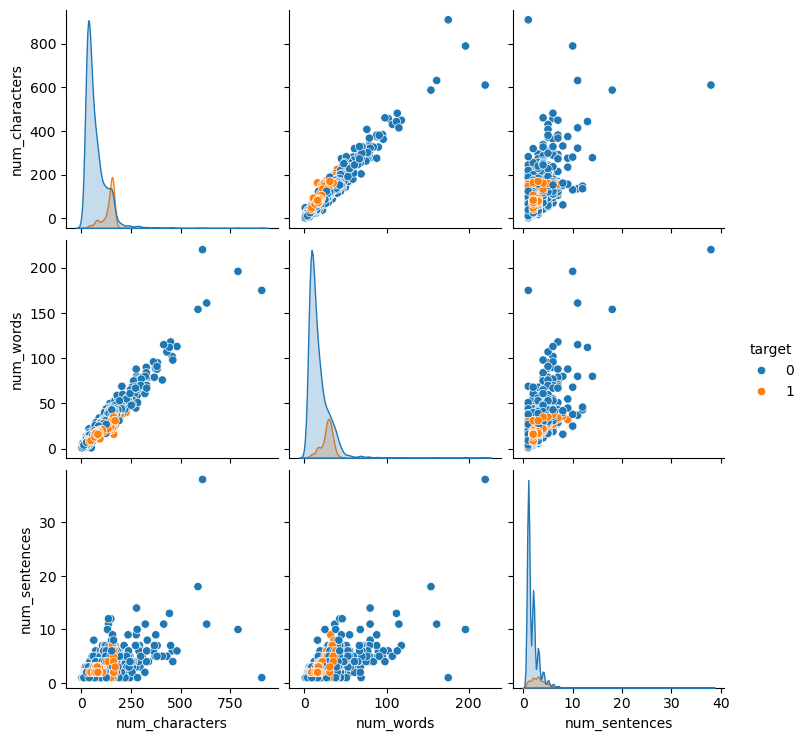

In [138]:
sns.pairplot(df,hue='target')

<Axes: >

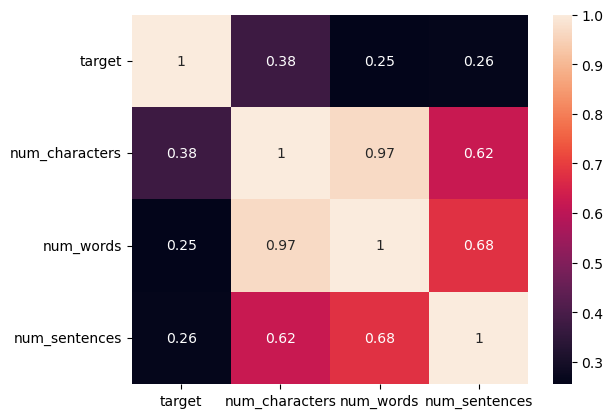

In [139]:
numeric_df = df.select_dtypes(include=[float, int])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True)

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [140]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer 

ps = PorterStemmer()

def transform_text(Email):
    # Lowercase
    Email = Email.lower()

    # Tokenization
    Email = nltk.word_tokenize(Email)

    # Removing Special Characters
    y = []
    for i in Email:
        if i.isalnum():
            y.append(i)
    Email = y[:]
    y.clear()

    # Stopwords
    for i in Email:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    # Stemming
    Email = y[:]
    y.clear()

    for i in Email:
        y.append(ps.stem(i))
    
    return " ".join(y)




In [141]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [142]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [143]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [144]:
df['transformed_text'] = df['text'].apply(transform_text)

In [145]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [146]:
from wordcloud import WordCloud
spam_text = df[df['target'] == 1]['transformed_text'].str.cat(sep=" ")
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [147]:
spam_wc = wc.generate(spam_text)

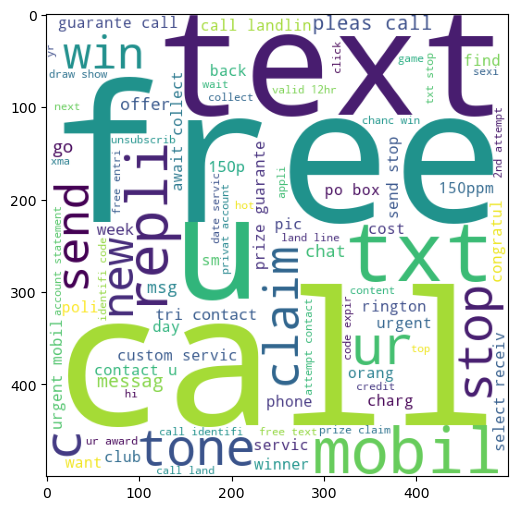

In [148]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [149]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

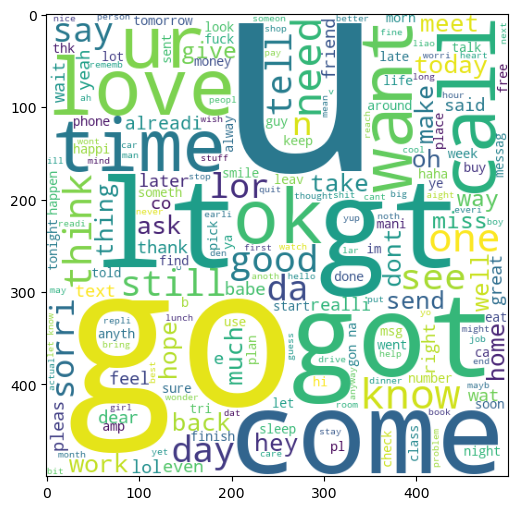

In [150]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [151]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [152]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [153]:
len(spam_corpus)

10178

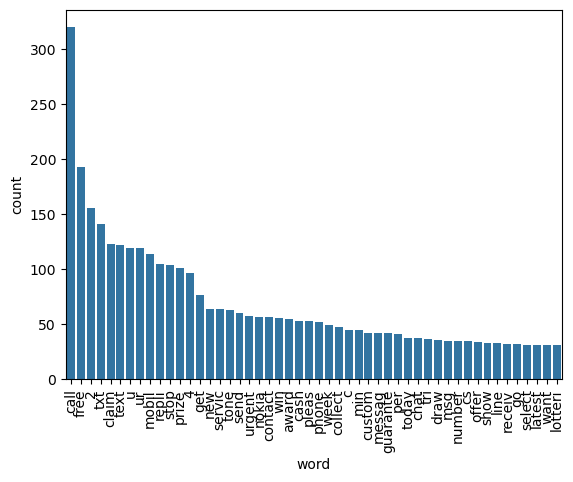

In [154]:
from collections import Counter
spam_common = pd.DataFrame(Counter(spam_corpus).most_common(50), columns=['word', 'count'])

# Plot using sns.barplot with the correct syntax
sns.barplot(x='word', y='count', data=spam_common)

# Rotate the x-axis labels for better readability
plt.xticks(rotation='vertical')

# Show the plot
plt.show()

In [155]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [156]:
len(ham_corpus)

35305

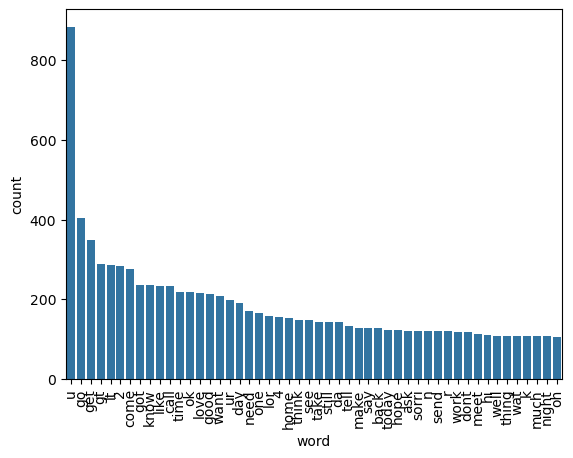

In [157]:
spam_common = pd.DataFrame(Counter(ham_corpus).most_common(50), columns=['word', 'count'])

# Plot using sns.barplot with the correct syntax
sns.barplot(x='word', y='count', data=spam_common)

# Rotate the x-axis labels for better readability
plt.xticks(rotation='vertical')

# Show the plot
plt.show()

In [158]:
# Text Vectorization
# using Bag of Words
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## 4. Model Building

In [159]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [160]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [161]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [162]:
# appending the num_character col to X
#X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [163]:
X.shape

(5205, 3000)

In [164]:
y = df['target'].values

In [165]:
from sklearn.model_selection import train_test_split

In [166]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [167]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [168]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [169]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8491834774255523
[[768 136]
 [ 21 116]]
0.4603174603174603


In [170]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9807877041306436
[[904   0]
 [ 20 117]]
1.0


In [171]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9855907780979827
[[903   1]
 [ 14 123]]
0.9919354838709677


In [172]:
# tfidf --> MNB

In [173]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [174]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [175]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [176]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [177]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9779058597502401, 0.9672131147540983)

In [178]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9779058597502401
Precision -  0.9672131147540983
For  KN
Accuracy -  0.9048991354466859
Precision -  1.0
For  NB
Accuracy -  0.9807877041306436
Precision -  1.0
For  DT
Accuracy -  0.9346781940441883
Precision -  0.8791208791208791
For  LR
Accuracy -  0.9500480307396734
Precision -  0.897196261682243
For  RF
Accuracy -  0.9817483189241114
Precision -  1.0


c:\Users\HP\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


For  AdaBoost
Accuracy -  0.9606147934678194
Precision -  0.8934426229508197
For  BgC
Accuracy -  0.9663784822286263
Precision -  0.9180327868852459
For  ETC
Accuracy -  0.9817483189241114
Precision -  0.9916666666666667
For  GBDT
Accuracy -  0.951969260326609
Precision -  0.9484536082474226
For  xgb
Accuracy -  0.9740634005763689
Precision -  0.9508196721311475


In [179]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [180]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.904899,1.000000
2,NB,0.980788,1.000000
5,RF,0.981748,1.000000
8,ETC,0.981748,0.991667
0,SVC,0.977906,0.967213
10,xgb,0.974063,0.950820
9,GBDT,0.951969,0.948454
7,BgC,0.966378,0.918033
4,LR,0.950048,0.897196
6,AdaBoost,0.960615,0.893443


In [181]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [182]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.904899
1,NB,Accuracy,0.980788
2,RF,Accuracy,0.981748
3,ETC,Accuracy,0.981748
4,SVC,Accuracy,0.977906
5,xgb,Accuracy,0.974063
6,GBDT,Accuracy,0.951969
7,BgC,Accuracy,0.966378
8,LR,Accuracy,0.950048
9,AdaBoost,Accuracy,0.960615


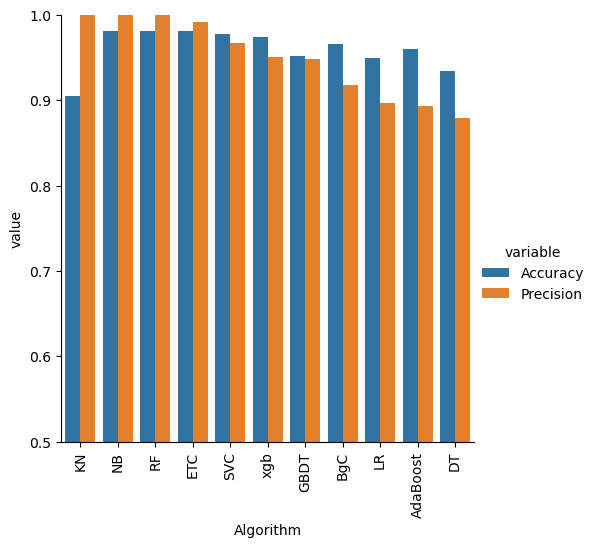

In [183]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [184]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [185]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [186]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [187]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [188]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [189]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [190]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.904899,1.000000,0.904899,1.000000,0.904899,1.000000,0.904899,1.000000
1,NB,0.980788,1.000000,0.980788,1.000000,0.980788,1.000000,0.980788,1.000000
2,RF,0.981748,1.000000,0.981748,1.000000,0.981748,1.000000,0.981748,1.000000
3,ETC,0.981748,0.991667,0.981748,0.991667,0.981748,0.991667,0.981748,0.991667
4,SVC,0.977906,0.967213,0.977906,0.967213,0.977906,0.967213,0.977906,0.967213
5,xgb,0.974063,0.950820,0.974063,0.950820,0.974063,0.950820,0.974063,0.950820
6,GBDT,0.951969,0.948454,0.951969,0.948454,0.951969,0.948454,0.951969,0.948454
7,BgC,0.966378,0.918033,0.966378,0.918033,0.966378,0.918033,0.966378,0.918033
8,LR,0.950048,0.897196,0.950048,0.897196,0.950048,0.897196,0.950048,0.897196
9,AdaBoost,0.960615,0.893443,0.960615,0.893443,0.960615,0.893443,0.960615,0.893443


In [191]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
#mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [192]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [193]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [194]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9846301633045149
Precision 1.0


In [195]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [196]:
from sklearn.ensemble import StackingClassifier

In [197]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [198]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.978866474543708
Precision 0.9389312977099237


In [199]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))